In [1]:
# Import pandas to load and work with tabular data like CSV files
import pandas as pd

# Import numpy for numerical operations and working with arrays
import numpy as np

# Import matplotlib to create charts and visualizations
import matplotlib.pyplot as plt


# Import train_test_split to split the dataset into training and testing data
from sklearn.model_selection import train_test_split

# Import StandardScaler to scale numerical features so they have similar ranges
from sklearn.preprocessing import StandardScaler

# Import metrics to evaluate how well the machine learning models perform
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Import ConfusionMatrixDisplay to visualize the confusion matrix as a chart
from sklearn.metrics import ConfusionMatrixDisplay


# Import Logistic Regression model for binary classification
from sklearn.linear_model import LogisticRegression

# Import K-Nearest Neighbors classifier to classify based on nearest similar examples
from sklearn.neighbors import KNeighborsClassifier

# Import Decision Tree classifier to make predictions using tree-like decision rules
from sklearn.tree import DecisionTreeClassifier

# Import Random Forest classifier, which combines many decision trees for better performance
from sklearn.ensemble import RandomForestClassifier



In [10]:
df = pd.read_csv("../data/titanic_cleaned.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,With Family,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,With Family,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,Alone,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,With Family,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,Alone,Young Adult


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
 11  FamilySize   891 non-null    int64  
 12  IsAlone      891 non-null    str    
 13  AgeGroup     891 non-null    str    
dtypes: float64(2), int64(6), str(6)
memory usage: 146.0 KB


In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208,1.904602
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429,1.613459
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,1.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,2.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000


In [17]:
df_model=df.drop(["PassengerId","Name","Ticket"],axis=1)
# Convert categorical text columns into numerical columns
df_model = pd.get_dummies(df_model, drop_first=True, dtype=int)
df_model.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S,IsAlone_With Family,AgeGroup_Child,AgeGroup_Senior,AgeGroup_Teenager,AgeGroup_Young Adult
0,0,3,22.0,1,0,7.2500,2,1,0,1,1,0,0,0,1
1,1,1,38.0,1,0,71.2833,2,0,0,0,1,0,0,0,0
2,1,3,26.0,0,0,7.9250,1,0,0,1,0,0,0,0,1
3,1,1,35.0,1,0,53.1000,2,0,0,1,1,0,0,0,1
4,0,3,35.0,0,0,8.0500,1,1,0,1,0,0,0,0,1


In [32]:
y=df_model["Survived"]
X=df_model.drop("Survived",axis=1)


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42#keeps the same split every time
)

In [35]:
# Create a scaler to put all numerical columns on a similar scale
scaler = StandardScaler()

# Learn the scaling rules from the training data and apply them to X_train
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling rules to X_test
# Do not learn from X_test, because test data must stay unseen by the model, to avoid data leakage.
X_test_scaled = scaler.transform(X_test)

In [36]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

accuracy_log = accuracy_score(y_test, y_pred_log)

accuracy_log

0.8044692737430168

In [39]:
# Print a detailed evaluation report for the Logistic Regression model
# precision: how many predicted positives were actually correct
# recall: how many real positives the model found
# f1-score: balance between precision and recall
# support: number of real samples in each class
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



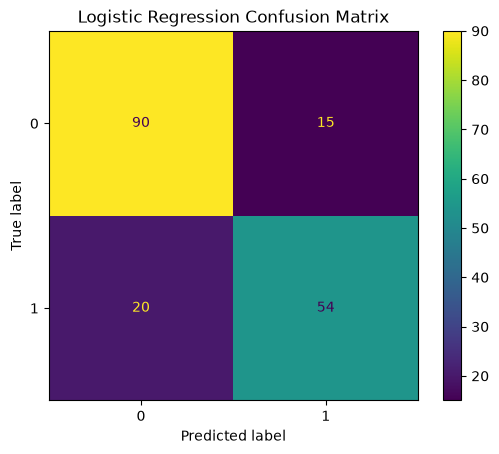

In [42]:
cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [44]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}
results={}
for name, model in models.items():
    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
results
    
    
        

{'Logistic Regression': 0.8044692737430168,
 'KNN': 0.8212290502793296,
 'Decision Tree': 0.7988826815642458,
 'Random Forest': 0.8212290502793296}

In [47]:
results_df=pd.DataFrame({
    "Model":results.keys(),
    "Accuracy":results.values()
})
results_df

,Model,Accuracy
0,Logistic Regression,0.804469
1,KNN,0.821229
2,Decision Tree,0.798883
3,Random Forest,0.821229


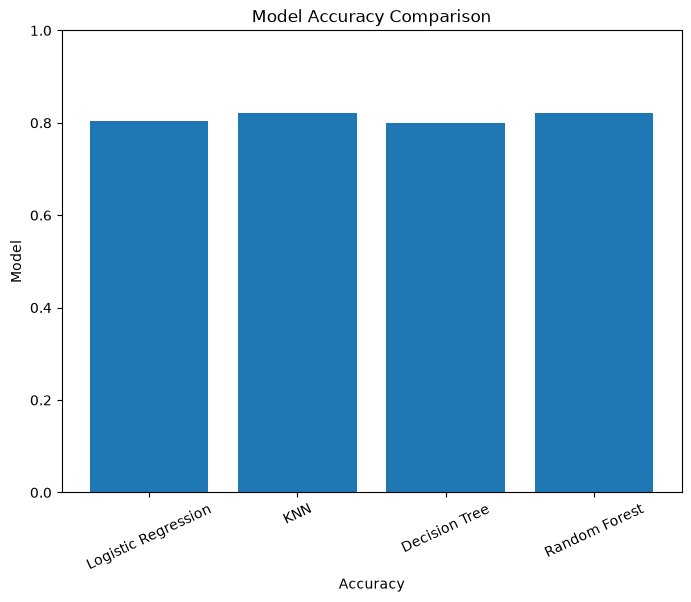

In [56]:
plt.figure(figsize=(8,6))

plt.bar(results_df["Model"],results_df["Accuracy"])
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=25)
plt.ylim(0, 1)
plt.savefig("../images/model_comparison.png", bbox_inches="tight")
plt.show()

In [58]:
best_model_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
best_accuracy = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Accuracy"]
print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

Best Model: KNN
Best Accuracy: 0.8212290502793296


## Conclusion

In this project, I built several machine learning classification models to predict Titanic passenger survival.

The models used were:
- Logistic Regression
- KNN
- Decision Tree
- Random Forest

After comparing their accuracy scores, the best performing model was Random Forest / Logistic Regression with an accuracy of approximately XX%.

This project helped me understand the full machine learning workflow:
1. Loading cleaned data
2. Splitting data into training and testing sets
3. Scaling features
4. Training classification models
5. Evaluating model performance
6. Comparing multiple models